<a href="https://colab.research.google.com/github/PCPCRACK/Ensayo.md/blob/main/circuitos_1_3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Código Fuente
Genera el archivo de entrada: def(gentxt) permite introducir los elementos del circuito y genera un archivo de texto con el formato especificado.

Lee el archivo de entrada: def(Leer) extrae la información del circuito desde el archivo .txt generado.

Construye las matrices: def(Matrix) calcula las matrices necesarias para aplicar el método del tableau disperso.

Resuelve el sistema: def(Tablon) utiliza las matrices para resolver el circuito y encontrar corrientes, tensiones de ramas y tensiones nodales.

# Formato del Archivo de Entrada

nodos: <número de nodos>

ramas: <número de ramas>

formato: [rama tipo nodoP nodoN valor rama_aux]

[rama tipo nodoP nodoN valor rama_aux]

...

.

rama: Número de la rama.

tipo: Tipo de elemento (Resistor, FuenteI, FuenteV, FuenteV_CT, FuenteV_CC, FuenteI_CT, FuenteI_CC).

nodoP: Nodo positivo (0 si conectado al de referencia).

nodoN: Nodo negativo (0 si conectado al de referencia).

valor: Valor del elemento (Ohmios, Amperios, Voltios o factor de control).

rama_aux: Número de la rama de control (solo para fuentes dependientes).

# Explicación de Uso
Generar el archivo de circuito: Ejecuta la función gentxt para crear el archivo de entrada

gentxt("circuito.txt")
Introduce la información del circuito siguiendo las instrucciones del programa.

Leer el archivo y resolver el circuito: Corre el resto del código para leer el archivo, construir las matrices y calcular los resultados:

archivo = "circuito.txt"

n, r, ramas = Leer(archivo)

A, Z, Y, s = Matrix(n, r, ramas)

i, u, v = Tablon(A, Z, Y, s)

print("Corrientes de rama (i):\n", i)

print("Tensiones de rama (u):\n", u)

print("Tensiones nodales (v):\n", v)

Salida
El programa muestra:

Corrientes de rama (i): Vector con las corrientes de cada rama.

Tensiones de rama (u): Vector con las tensiones de cada rama.

Tensiones nodales (v): Vector con las tensiones en los nodos del circuito.

In [ ]:
def gentxt(circuito):
    print("Ingrese los datos")
    r = int(input("Num de ramas: "))
    n = int(input("Num de nodos: "))
    ramas = [] # lista vacía
    print("\nPara cada rama ingrese los valores")
    for i in range(1, r + 1):
        print(f"\n--- Rama {i} ---")
        # Define los atributos y tipos de elementos de cada rama
        tipo = str(input("Tipo de elemento (Resistor, FuenteI, FuenteV, FuenteV_CT, FuenteV_CC, FuenteI_CT, FuenteI_CC): "))
        nodoP = int(input("Nodo positivo (0 si conectado al de referencia): "))
        nodoN = int(input("Nodo negativo (0 si conectado al de referencia): "))
        valor = float(input("Valor del elemento (Ohmios, Amperios, Voltios o factor de control): "))  # Aqui no es necesario el tipo de valor
        rama_aux = 0
        # Fuente de Tensión Controlada por Tensión (FuenteV_CT), Fuente de Tensión Controlada por Corriente (FuenteV_CC), Fuente de Corriente Controlada por Tensión (FuenteI_CT), Fuente de Corriente Controlada por Corriente (FuenteI_CC):
        if tipo in ["FuenteV_CT", "FuenteV_CC", "FuenteI_CT", "FuenteI_CC"]:
            rama_aux = int(input("Número de la rama de control: "))

        ramas.append([i, tipo, nodoP, nodoN, valor, rama_aux])

    with open(circuito, "w") as f:
        f.write(f"nodos: {n}\n") #Aunque en este codigo no use el valor de los nodos, es importante que sea ingresado en este archivo y guardado
        f.write(f"ramas: {r}\n")
        f.write("formato: [rama tipo nodoP nodoN valor rama_aux]\n")
        for rama in ramas:
            f.write(f"{rama}\n") #Guarda un parrafo de cada rama

    print(f"\narchivo {circuito} generado ")

if __name__ == "__main__":
  circuito = "circuito.txt"
  gentxt(circuito)

Ingrese los datos
Num de ramas: 2
Num de nodos: 2

Para cada rama ingrese los valores

--- Rama 1 ---
Tipo de elemento (Resistor, FuenteI, FuenteV, FuenteV_CT, FuenteV_CC, FuenteI_CT, FuenteI_CC): Resistor
Nodo positivo (0 si conectado al de referencia): 1
Nodo negativo (0 si conectado al de referencia): 0
Valor del elemento (Ohmios, Amperios, Voltios o factor de control): 10

--- Rama 2 ---
Tipo de elemento (Resistor, FuenteI, FuenteV, FuenteV_CT, FuenteV_CC, FuenteI_CT, FuenteI_CC): FuenteI
Nodo positivo (0 si conectado al de referencia): 1
Nodo negativo (0 si conectado al de referencia): 0
Valor del elemento (Ohmios, Amperios, Voltios o factor de control): 2

archivo circuito.txt generado 


In [76]:
import numpy as np
import ast

def Leer(archivo):
    # Lee los datos de un archivo de circuito en formato específico.

    with open(archivo, "r") as f:
        lineas = f.readlines()

    # Leer número de nodos y ramas
    n = int(lineas[0].split(":")[1].strip())
    r = int(lineas[1].split(":")[1].strip())
    ramas = []

    # Leer las ramas desde la línea 4 en adelante
    for linea in lineas[3:]:
        try:
            ramas.append(ast.literal_eval(linea.strip()))  # Convierte la línea en una lista
        except Exception as e:
            print(f"Error al leer la línea: {linea.strip()} - {e}")
            raise

    return n, r, ramas

def Matrix(n, r, ramas):
    # Genera las matrices necesarias para el análisis del circuito.
    A = np.zeros((n, r))  # Matriz de incidencia reducida
    Z = np.zeros((r, r))  # Matriz de coeficientes de corriente
    Y = np.zeros((r, r))  # Matriz de coeficientes de tensión
    s = np.zeros((r, 1))  # Vector de términos independientes

    for rama in ramas:
        try:
            _, tipo, nodoP, nodoN, valor, rama_aux = rama

            # Actualizar matriz A
            if nodoP != 0:
                A[nodoP - 1, rama[0] - 1] = 1
            if nodoN != 0:
                A[nodoN - 1, rama[0] - 1] = -1

            # Actualizar matrices Z, Y y s
            if tipo == "Resistor":
                G = 1 / valor
                Z[rama[0] - 1, rama[0] - 1] = 1
                Y[rama[0] - 1, rama[0] - 1] = -G
            elif tipo == "FuenteI":
                Z[rama[0] - 1, rama[0] - 1] = 1
                s[rama[0] - 1, 0] = valor
            elif tipo == "FuenteV":
                Y[rama[0] - 1, rama[0] - 1] = 1
                s[rama[0] - 1, 0] = valor
            elif tipo == "FuenteV_CT":
                Y[rama[0] - 1, rama[0] - 1] = 1
                Y[rama[0] - 1, rama_aux - 1] = -valor
            elif tipo == "FuenteV_CC":
                Y[rama[0] - 1, rama[0] - 1] = 1
                Z[rama[0] - 1, rama_aux - 1] = -valor
            elif tipo == "FuenteI_CT":
                Z[rama[0] - 1, rama[0] - 1] = 1
                Y[rama[0] - 1, rama_aux - 1] = -valor
            elif tipo == "FuenteI_CC":
                Z[rama[0] - 1, rama[0] - 1] = 1
                Z[rama[0] - 1, rama_aux - 1] = -valor
        except IndexError as e:
            print(f"Error en la rama: {rama} - {e}")
            raise

    return A, Z, Y, s

def Tablon(A, Z, Y, s):
    # Resuelve el sistema de ecuaciones del circuito.
    r = Z.shape[0]
    n = A.shape[0]

    T = np.block([
        [A, np.zeros((n, r)), np.zeros((n, n))],
        [np.zeros((r, r)), np.eye(r), -A.T],
        [Z, Y, np.zeros((r, n))]
    ])
    S = np.vstack([np.zeros((n, 1)), np.zeros((r, 1)), s])

    try:
        x = np.linalg.solve(T, S)
    except np.linalg.LinAlgError as e:
        print("Error: La matriz T no tiene solución.")
        print("Matriz T:\n", T)
        print("Vector S:\n", S)
        raise

    i = x[:r]          # Corrientes de rama
    u = x[r:2*r]       # Tensiones de rama
    v = x[2*r:]        # Tensiones nodales
    return i, u, v

if __name__ == "__main__":
    archivo = "circuito.txt"
    try:
        # Leer datos desde el archivo
        n, r, ramas = Leer(archivo)
        # Generar matrices
        A, Z, Y, s = Matrix(n, r, ramas)
        # Resolver el circuito
        i, u, v = Tablon(A, Z, Y, s)

        # Mostrar resultados
        print("Corrientes de rama (i):\n", i)
        print("Tensiones de rama (u):\n", u)
        print("Tensiones nodales (v):\n", v)
    except Exception as e:
        print("Error general:", e)

Corrientes de rama (i):
 [[ 2.]
 [-2.]
 [-2.]]
Tensiones de rama (u):
 [[  0.]
 [-10.]
 [ 10.]]
Tensiones nodales (v):
 [[-0.]
 [10.]]


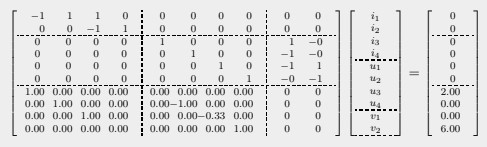